# **Large Language Models Lab(MCSE642P)**

# CNN for Image Classification
**SHRIHARIHARAN S (24MCS1058)**

**M.TECH CSE 1ST YEAR**




 ---------------------

*we have taken the Fashion_mnist dataset and developed the different CNN models with various dense layers and various epochs and check the performance of the each CNN model*

In [1]:
from keras.datasets import fashion_mnist
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers  import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.optimizers import SGD, Adam, RMSprop
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# CIFAR_10 is a set of 60K images 32x32 pixels on 3 channels
IMG_CHANNELS = 1
IMG_ROWS = 28
IMG_COLS = 28

In [3]:
#constant
BATCH_SIZE = 128
#NB_EPOCH = 20
NB_EPOCH = 40
NB_CLASSES = 10
VERBOSE = 1
VALIDATION_SPLIT = 0.2
OPTIM = Adam()

In [4]:
#load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
print('X_train shape:', X_train.shape)
print(X_train.shape[0], 'train samples')
print(X_test.shape[0], 'test samples')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 28, 28)
60000 train samples
10000 test samples


In [5]:
# convert to categorical
Y_train = to_categorical(y_train, NB_CLASSES)
Y_test = to_categorical(y_test, NB_CLASSES)

In [6]:
# float and normalization
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

In [7]:
#Model1
model = Sequential()
model.add(Conv2D(28, (3, 3), padding='same',input_shape=(IMG_ROWS, IMG_COLS, IMG_CHANNELS)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.add(Flatten())
model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(NB_CLASSES))
model.add(Activation('softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 28)          │             280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 28, 28, 28)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 28)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 14, 28)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 5488)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       2,810,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           5,130 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,815,778 (10.74 MB)

 Trainable params: 2,815,778 (10.74 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# train
model.compile(loss='categorical_crossentropy', optimizer=OPTIM, metrics=['accuracy'])

In [10]:
history=model.fit(X_train, Y_train, batch_size=BATCH_SIZE,epochs=20, validation_split=VALIDATION_SPLIT,verbose=VERBOSE)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7596 - loss: 0.6757 - val_accuracy: 0.8827 - val_loss: 0.3272
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8797 - loss: 0.3381 - val_accuracy: 0.8952 - val_loss: 0.2862
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8953 - loss: 0.2900 - val_accuracy: 0.9032 - val_loss: 0.2625
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9072 - loss: 0.2514 - val_accuracy: 0.9074 - val_loss: 0.2549
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9104 - loss: 0.2422 - val_accuracy: 0.9112 - val_loss: 0.2412
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9149 - loss: 0.2328 - val_accuracy: 0.9145 - val_loss: 0.2382
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9231 - loss: 0.2055 - val_accuracy: 0.9125 - val_loss: 0.2366
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9295 - loss: 0.1929 - val_accuracy: 0.

In [11]:
score = model.evaluate(X_test, Y_test,batch_size=BATCH_SIZE, verbose=VERBOSE)
print("Test loss:", score[0])
print('Test accuracy:', score[1])

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9198 - loss: 0.2570
Test loss: 0.2564760148525238
Test accuracy: 0.9193999767303467


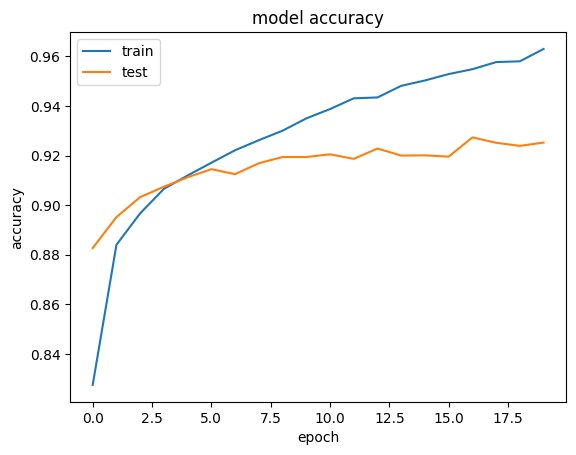

In [12]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

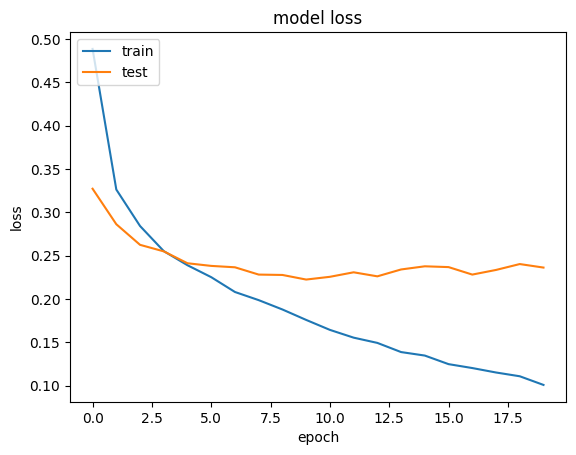

In [13]:
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [14]:
#save model
model_json = model.to_json()
open('fashion_mnist_architecture.json', 'w').write(model_json)
#And the weights learned by our deep network on the training set
# The filename must end in .weights.h5
model.save_weights('fashion_mnist_weights.weights.h5', overwrite=True)

In [24]:
#Improving the Fashion_Mnist performance with a deeper network
model = Sequential()
model.add(Conv2D(28, (3, 3), padding='same',
input_shape=(IMG_ROWS, IMG_COLS, IMG_CHANNELS)))
model.add(Activation('relu'))
model.add(Conv2D(32, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Conv2D(64, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(Conv2D(128, (3, 3), padding='same'))
model.add(Activation('relu'))
model.add(Conv2D(256, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(512))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(NB_CLASSES))
model.add(Activation('softmax'))

In [25]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 28)          │             280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 28, 28, 28)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 28, 28, 32)          │           8,096 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 14, 14, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_6 (Activation)            │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 12, 12, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_7 (Activation)            │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 512)                 │       4,719,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_8 (Activation)            │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 10)                  │           5,130 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_9 (Activation)            │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,120,130 (19.53 MB)

 Trainable params: 5,120,130 (19.53 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Create a new optimizer instance for the new model
OPTIM = Adam() # Or any other optimizer you prefer

# train
model.compile(loss='categorical_crossentropy', optimizer=OPTIM, metrics=['accuracy']) # Now using the new optimizer instance

In [27]:
model.fit(X_train, Y_train, batch_size=BATCH_SIZE,epochs=NB_EPOCH, validation_split=VALIDATION_SPLIT,verbose=VERBOSE)

Epoch 1/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 26ms/step - accuracy: 0.7131 - loss: 0.7789 - val_accuracy: 0.8798 - val_loss: 0.3297
Epoch 2/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.8771 - loss: 0.3308 - val_accuracy: 0.9018 - val_loss: 0.2740
Epoch 3/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9017 - loss: 0.2690 - val_accuracy: 0.9158 - val_loss: 0.2336
Epoch 4/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9132 - loss: 0.2351 - val_accuracy: 0.9191 - val_loss: 0.2169
Epoch 5/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9217 - loss: 0.2106 - val_accuracy: 0.9197 - val_loss: 0.2195
Epoch 6/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9268 - loss: 0.1983 - val_accuracy: 0.9169 - val_loss: 0.2210
Epoch 7/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9343 - loss: 0.1775 - val_accuracy: 0.9302 - val_loss: 0.1950
Epoch 8/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9416 - loss: 0.1607 - val_

In [28]:
score = model.evaluate(X_test, Y_test,
batch_size=BATCH_SIZE, verbose=VERBOSE)
print("Test loss:", score[0])
print('Test accuracy:', score[1])

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9337 - loss: 0.3544
Test loss: 0.36239078640937805
Test accuracy: 0.933899998664856


In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [30]:
pred1 = model.predict(X_test)
pred1 = np.argmax(pred1, axis = 1)
label1 = np.argmax(Y_test,axis = 1)
print(pred1)
print(label1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[9 2 1 ... 8 1 5]
[9 2 1 ... 8 1 5]


In [31]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(label1, pred1)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9339


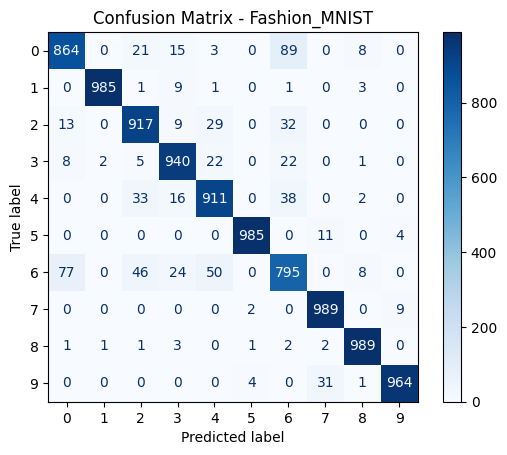

In [32]:
conf_matrix = confusion_matrix(label1, pred1)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Fashion_MNIST")
plt.show()

**Inference:**


*   With only ANN With ustomized Neural Network with multiple dense layers acquired the overall test accuracy score of 89.11% (Total params: 244,522), Optimizer-ADAM, Epochs-100

*   Model1: with one convolution and few dense layer (Total params: 2,815,778) -achieved overall test accuracy score of 91.93999767303467%,
 Epochs-20


*  Model2: customised with multiple convolution and dense layers (Total params: 5,120,130)-achieved overall test accuracy score of 93.3899998664856%,Epochs-40




*   We also saved the model in fashion_mnist_architecture.json format
*   And saved the weights infashion_mnist_weights.weights.h5 format



